In [20]:
import pandas as pd

# CSV dosyasını okuyup bir veri çerçevesine (dataframe) alıyoruz
df = pd.read_csv('creditcard.csv')

# Verinin ilk 5 satırını ekrana yazdırıyoruz
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [21]:
# Sınıfların (0: Normal, 1: Sahte) dağılımını görelim
sinif_dagilimi = df['Class'].value_counts()
print("Sınıf Dağılımı:\n", sinif_dagilimi)

# Sahtekarlık oranını hesaplayalım
sahte_orani = (sinif_dagilimi[1] / float(len(df))) * 100
print(f"\nSahtekarlık Oranı: % {sahte_orani:.3f}")


Sınıf Dağılımı:
 Class
0    284315
1       492
Name: count, dtype: int64

Sahtekarlık Oranı: % 0.173


In [22]:
# Hedef değişken (y) ve özellikler (X) olarak ayırıyoruz
X = df.drop('Class', axis=1)
y = df['Class']

In [24]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Veriyi Eğitim (%80) ve Test (%20) olarak ayırıyoruz
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# SMOTE'u sadece EĞİTİM verisine uyguluyoruz
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("SMOTE Öncesi Eğitim Verisi Sınıf Dağılımı:\n", y_train.value_counts())
print("\nSMOTE Sonrası Eğitim Verisi Sınıf Dağılımı:\n", y_train_smote.value_counts())

SMOTE Öncesi Eğitim Verisi Sınıf Dağılımı:
 Class
0    227451
1       394
Name: count, dtype: int64

SMOTE Sonrası Eğitim Verisi Sınıf Dağılımı:
 Class
0    227451
1    227451
Name: count, dtype: int64


In [25]:
from sklearn.ensemble import RandomForestClassifier

# Modeli oluşturuyoruz (n_estimators=100 demek, 100 tane karar ağacı kullanacağız demek)
# n_jobs=-1 parametresi, bilgisayarının tüm işlemci gücünü kullanmasını sağlar, işlemi hızlandırır.
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

print("Model eğitiliyor, bu işlem bilgisayarının hızına göre 1-2 dakika sürebilir. Lütfen bekle...")

# Modeli SMOTE uygulanmış Eğitim verimizle "fit" ediyoruz (yani eğitiyoruz)
model.fit(X_train_smote, y_train_smote)

print("Eğitim tamamlandı! Model artık sahtekarlığı tanımaya hazır.")

Model eğitiliyor, bu işlem bilgisayarının hızına göre 1-2 dakika sürebilir. Lütfen bekle...
Eğitim tamamlandı! Model artık sahtekarlığı tanımaya hazır.


Sınıflandırma Raporu (Classification Report):

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.85      0.86        98

    accuracy                           1.00     56962
   macro avg       0.94      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962



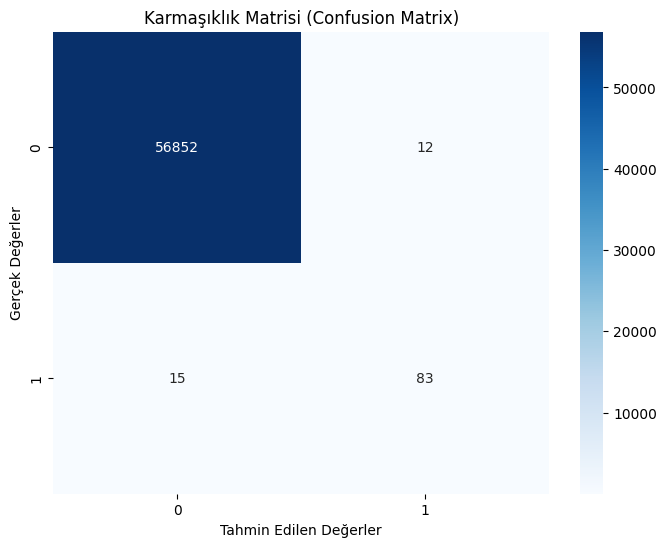

In [27]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Modelden, X_test (özellikler) verisine bakarak y_test'i (hedefi) tahmin etmesini istiyoruz
y_pred = model.predict(X_test)

# Sonuçları değerlendirelim
print("Sınıflandırma Raporu (Classification Report):\n")
print(classification_report(y_test, y_pred))

# Karmaşıklık Matrisi (Confusion Matrix) Çizdirme
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Karmaşıklık Matrisi (Confusion Matrix)")
plt.ylabel('Gerçek Değerler')
plt.xlabel('Tahmin Edilen Değerler')
plt.show()

In [28]:
import pandas as pd
from datetime import datetime
import os
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Performans metriklerini sklearn ile matematiksel olarak hesaplıyoruz
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# cm değişkeni bir önceki hücreden geliyor (Confusion Matrix)
tn, fp, fn, tp = cm.ravel()

# Excel'e yazdırılacak tek satırlık yeni veriyi hazırlıyoruz
yeni_kayit = pd.DataFrame([{
    "Tarih": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "Model": "Random Forest",
    "Veri Durumu": "SMOTE Uygulandı (Eğitim Setine)",
    "Accuracy (Genel)": f"%{acc*100:.2f}",
    "Precision (Kesinlik)": f"%{prec*100:.2f}",
    "Recall (Sahtekarı Yakalama)": f"%{rec*100:.2f}",
    "F1-Score": f"%{f1*100:.2f}",
    "Kaçan Sahtekarlar (FN)": fn,
    "Yanlış Alarmlar (FP)": fp
}])

# Dosya adı (Excel ile doğrudan açılabilen CSV formatı)
dosya_adi = "Model_Performans_Raporu.csv"

# Eğer dosya yoksa başlıklarla beraber yarat, varsa sadece alt satıra ekle
try:
    if not os.path.isfile(dosya_adi):
        yeni_kayit.to_csv(dosya_adi, index=False, encoding='utf-8-sig') # utf-8-sig Türkçe karakterleri Excel'de bozmaz
    else:
        yeni_kayit.to_csv(dosya_adi, mode='a', header=False, index=False, encoding='utf-8-sig')
    print(f"Rapor başarıyla {dosya_adi} dosyasına kaydedildi! Gidip klasörden Excel ile açabilirsin.")
except PermissionError:
    print(f"Dosya {dosya_adi} açık olabilir. Farklı bir dosya adı ile kaydediliyor: Model_Performans_Raporu_backup.csv")
    yeni_kayit.to_csv("Model_Performans_Raporu_backup.csv", index=False, encoding='utf-8-sig')
    print("Rapor başarıyla Model_Performans_Raporu_backup.csv dosyasına kaydedildi!")

Dosya Model_Performans_Raporu.csv açık olabilir. Farklı bir dosya adı ile kaydediliyor: Model_Performans_Raporu_backup.csv
Rapor başarıyla Model_Performans_Raporu_backup.csv dosyasına kaydedildi!


In [29]:
import joblib
#Şu an model sadece Python'ın geçici hafızasında. Onu bir dosya olarak kaydetmeliyiz ki API dosyamız onu okuyabilsin.
# Modeli 'random_forest_model.pkl' adıyla diske kaydediyoruz
joblib.dump(model, 'random_forest_model.pkl')
print("Model başarıyla paketlendi ve kaydedildi!")

Model başarıyla paketlendi ve kaydedildi!


In [30]:
import pandas as pd
import numpy as np
from scipy import stats

# 1. ÖZELLİK MÜHENDİSLİĞİ (Feature Engineering)
# Saniyeleri (Time) günün saatine (0-23) ve güne (0-1) çeviriyoruz
df['Hour'] = (df['Time'] // 3600) % 24
df['Day'] = (df['Time'] // (3600 * 24))

# Artık işimiz kalmayan eski Time kolonunu siliyoruz
df = df.drop(['Time'], axis=1)

# 2. AYKIRI DEĞER ANALİZİ (Outlier Analysis) - Z-Skoru
# SADECE Normal işlemlerdeki (Class 0) aşırı uçuk değerleri siliyoruz ki sahtekarları kaybetmeyelim.
normal_islemler = df[df['Class'] == 0]
sahte_islemler = df[df['Class'] == 1]

# V1'den V28'e ve Amount kolonuna Z-skoru uyguluyoruz (Eşik değer: 3)
z_skorlari = np.abs(stats.zscore(normal_islemler.drop(['Class', 'Hour', 'Day'], axis=1)))
temiz_normal_islemler = normal_islemler[(z_skorlari < 3).all(axis=1)]

# Temizlenmiş normal verilerle sahtekarları tekrar birleştiriyoruz
df_temiz = pd.concat([temiz_normal_islemler, sahte_islemler])

print(f"Orijinal Veri Sayısı: {len(df)}")
print(f"Temizlenmiş Veri Sayısı: {len(df_temiz)}")
print(f"Silinen Aykırı Değer Sayısı: {len(df) - len(df_temiz)}")

Orijinal Veri Sayısı: 284807
Temizlenmiş Veri Sayısı: 244647
Silinen Aykırı Değer Sayısı: 40160


In [31]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

# 1. X (Özellikler) ve y (Hedef) Olarak Ayırma
# Temizlenmiş veri setimizi (df_temiz) kullanıyoruz
X = df_temiz.drop('Class', axis=1)
y = df_temiz['Class']

# 2. Veriyi Eğitim (%80) ve Test (%20) Olarak Bölme
# stratify=y parametresi, sahte işlemlerin her iki tarafa eşit oranda dağılmasını sağlar
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. SMOTE İşlemi (SADECE Eğitim Verisine Uyguluyoruz)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"SMOTE Öncesi Eğitim Setindeki Sahte İşlem: {sum(y_train == 1)}")
print(f"SMOTE Sonrası Eğitim Setindeki Sahte İşlem: {sum(y_train_smote == 1)}")

# 4. Yeni Modeli Eğitme (Random Forest)
print("Yeni özelliklerle (Saat, Gün) model eğitiliyor, bu işlem birkaç dakika sürebilir...")

model = RandomForestClassifier(random_state=42)
model.fit(X_train_smote, y_train_smote)

print("Harika! Model yepyeni özelliklerle başarıyla eğitildi!")

SMOTE Öncesi Eğitim Setindeki Sahte İşlem: 394
SMOTE Sonrası Eğitim Setindeki Sahte İşlem: 195323
Yeni özelliklerle (Saat, Gün) model eğitiliyor, bu işlem birkaç dakika sürebilir...
Harika! Model yepyeni özelliklerle başarıyla eğitildi!


Sahte ve Normal İşlem Ortalamaları Tablosu:
Özellik  Normal İşlemler Ortalama  Sahte İşlemler Ortalama
 Amount                 88.291022               122.211321
   Hour                 14.050623                11.646341
     V1                  0.008258                -4.771948
    V10                  0.009824                -5.676883
    V12                  0.010832                -6.259393
    V14                  0.012064                -6.971723


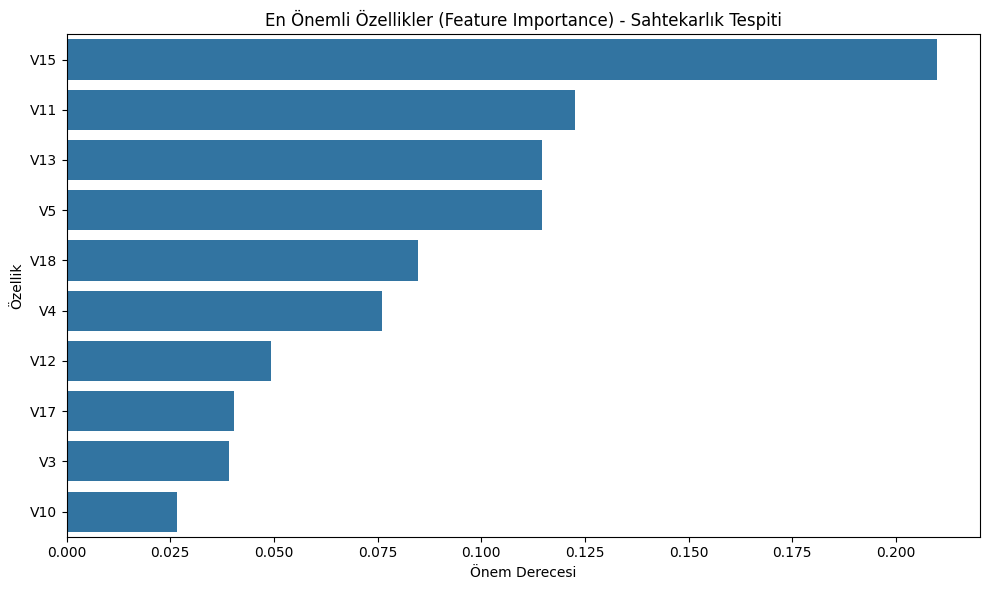


Senaryo Örnekleri:
                       Senaryo  Amount  Hour       V14  Sahtekarlık Olasılığı (%)
            Normal Kahve Alışı       5     8  0.012064                        0.0
 Şüpheli Harcama (V14 anormal)     500     2 -6.971723                        0.0
Çok Şüpheli (Tüm Vler anormal)     500     2 -6.971723                       13.0

Rapor için dosyalar kaydedildi: ortalamalar_tablosu.csv, feature_importance.png, senaryo_ornekleri.csv


c:\Users\emelk\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\emelk\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\emelk\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [34]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Modeli yükle
model = joblib.load('random_forest_model.pkl')

# Özellik isimleri (model 30 feature bekliyor, Day çıkarıldı)
features = ['V1','V2','V3','V4','V5','V6','V7','V8','V9','V10','V11','V12','V13','V14','V15','V16','V17','V18','V19','V20','V21','V22','V23','V24','V25','V26','V27','V28','Amount','Hour']

# Feature importances
importances = model.feature_importances_

# Veri setini yükle
df = pd.read_csv('creditcard.csv')
df['Hour'] = (df['Time'] // 3600) % 24
df['Day'] = (df['Time'] // (3600 * 24))

# Sahte ve normal işlemler
fraud = df[df['Class'] == 1]
normal = df[df['Class'] == 0]

# Tablo için ortalamalar
averages = pd.DataFrame({
    'Özellik': ['Amount', 'Hour', 'V1', 'V10', 'V12', 'V14'],
    'Normal İşlemler Ortalama': [
        normal['Amount'].mean(),
        normal['Hour'].mean(),
        normal['V1'].mean(),
        normal['V10'].mean(),
        normal['V12'].mean(),
        normal['V14'].mean()
    ],
    'Sahte İşlemler Ortalama': [
        fraud['Amount'].mean(),
        fraud['Hour'].mean(),
        fraud['V1'].mean(),
        fraud['V10'].mean(),
        fraud['V12'].mean(),
        fraud['V14'].mean()
    ]
})

print("Sahte ve Normal İşlem Ortalamaları Tablosu:")
print(averages.to_string(index=False))

# Tabloyu CSV'ye kaydet
averages.to_csv('ortalamalar_tablosu.csv', index=False, encoding='utf-8-sig')

# Feature Importance Grafiği (Top 10)
top_features = sorted(zip(features, importances), key=lambda x: x[1], reverse=True)[:10]
feat_names, feat_imps = zip(*top_features)

plt.figure(figsize=(10, 6))
sns.barplot(x=list(feat_imps), y=list(feat_names))
plt.title('En Önemli Özellikler (Feature Importance) - Sahtekarlık Tespiti')
plt.xlabel('Önem Derecesi')
plt.ylabel('Özellik')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

# Daha şüpheli senaryo: Tüm V'ler fraud ortalaması
highly_suspicious_input = {
    'V1': fraud['V1'].mean(),
    'V2': fraud['V2'].mean(),
    'V3': fraud['V3'].mean(),
    'V4': fraud['V4'].mean(),
    'V5': fraud['V5'].mean(),
    'V6': fraud['V6'].mean(),
    'V7': fraud['V7'].mean(),
    'V8': fraud['V8'].mean(),
    'V9': fraud['V9'].mean(),
    'V10': fraud['V10'].mean(),
    'V11': fraud['V11'].mean(),
    'V12': fraud['V12'].mean(),
    'V13': fraud['V13'].mean(),
    'V14': fraud['V14'].mean(),
    'V15': fraud['V15'].mean(),
    'V16': fraud['V16'].mean(),
    'V17': fraud['V17'].mean(),
    'V18': fraud['V18'].mean(),
    'V19': fraud['V19'].mean(),
    'V20': fraud['V20'].mean(),
    'V21': fraud['V21'].mean(),
    'V22': fraud['V22'].mean(),
    'V23': fraud['V23'].mean(),
    'V24': fraud['V24'].mean(),
    'V25': fraud['V25'].mean(),
    'V26': fraud['V26'].mean(),
    'V27': fraud['V27'].mean(),
    'V28': fraud['V28'].mean(),
    'Amount': 500,
    'Hour': 2
}

# Senaryo: Ahmet Bey örneği (30 feature)
scenario_input = {
    'V1': normal['V1'].mean(),
    'V2': normal['V2'].mean(),
    'V3': normal['V3'].mean(),
    'V4': normal['V4'].mean(),
    'V5': normal['V5'].mean(),
    'V6': normal['V6'].mean(),
    'V7': normal['V7'].mean(),
    'V8': normal['V8'].mean(),
    'V9': normal['V9'].mean(),
    'V10': normal['V10'].mean(),
    'V11': normal['V11'].mean(),
    'V12': normal['V12'].mean(),
    'V13': normal['V13'].mean(),
    'V14': normal['V14'].mean(),
    'V15': normal['V15'].mean(),
    'V16': normal['V16'].mean(),
    'V17': normal['V17'].mean(),
    'V18': normal['V18'].mean(),
    'V19': normal['V19'].mean(),
    'V20': normal['V20'].mean(),
    'V21': normal['V21'].mean(),
    'V22': normal['V22'].mean(),
    'V23': normal['V23'].mean(),
    'V24': normal['V24'].mean(),
    'V25': normal['V25'].mean(),
    'V26': normal['V26'].mean(),
    'V27': normal['V27'].mean(),
    'V28': normal['V28'].mean(),
    'Amount': 5,
    'Hour': 8
}

suspicious_input = scenario_input.copy()
suspicious_input['Amount'] = 500
suspicious_input['Hour'] = 2
suspicious_input['V14'] = fraud['V14'].mean()

normal_pred = model.predict_proba([list(scenario_input.values())])
suspicious_pred = model.predict_proba([list(suspicious_input.values())])
highly_suspicious_pred = model.predict_proba([list(highly_suspicious_input.values())])

scenario_results = pd.DataFrame({
    'Senaryo': ['Normal Kahve Alışı', 'Şüpheli Harcama (V14 anormal)', 'Çok Şüpheli (Tüm Vler anormal)'],
    'Amount': [5, 500, 500],
    'Hour': [8, 2, 2],
    'V14': [scenario_input['V14'], suspicious_input['V14'], highly_suspicious_input['V14']],
    'Sahtekarlık Olasılığı (%)': [normal_pred[0][1]*100, suspicious_pred[0][1]*100, highly_suspicious_pred[0][1]*100]
})

print("\nSenaryo Örnekleri:")
print(scenario_results.to_string(index=False))

scenario_results.to_csv('senaryo_ornekleri.csv', index=False, encoding='utf-8-sig')

print("\nRapor için dosyalar kaydedildi: ortalamalar_tablosu.csv, feature_importance.png, senaryo_ornekleri.csv")